In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
import torch
import librosa
import librosa.display
from tqdm.auto import tqdm

In [207]:
from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

from pathlib import Path
import pandas as pd
import json
import numpy as np

# ============================================================
# 1. Chemins principaux
# ============================================================

# Dossier principal du projet sur Google Drive
# On l'utilise pour sauvegarder les checkpoints, les figures et les résultats.
PROJECT_DIR = Path("/content/drive/MyDrive/DiffWave_Darija")

# # Dossier contenant les données prétraitées sur Google Drive
DRIVE_DATA_DIR = PROJECT_DIR / "data_preprocessed"

# # Dossier local temporaire dans Colab
# # On copie les données ici pour accélérer l'entraînement.
LOCAL_DATA_DIR = Path("/content/drive/MyDrive/DiffWave_Darija/data_preprocessed")

# # ============================================================
# # 2. Copie des données depuis Google Drive vers /content
# # ============================================================

# # Cette copie évite de lire des milliers de petits fichiers directement depuis Google Drive.
# # Si le dossier local existe déjà, on ne recopie pas.
# if not LOCAL_DATA_DIR.exists():
#     print("Copie des données depuis Google Drive vers /content...")
#     !cp -r "/content/drive/MyDrive/DiffWave_Darija/data_preprocessed" "/content/data_preprocessed"
#     print("Copie terminée.")
# else:
#     print("Les données sont déjà présentes dans /content.")

# À partir d'ici, on utilise les données locales pour l'entraînement.
DATA_DIR = LOCAL_DATA_DIR

# ============================================================
# 3. Définition des fichiers et dossiers utiles
# ============================================================

TRAIN_CSV = DATA_DIR / "train.csv"
VAL_CSV = DATA_DIR / "val.csv"
TEST_CSV = DATA_DIR / "test.csv"
SUMMARY_JSON = DATA_DIR / "summary.json"

WAV_DIR = DATA_DIR / "wavs"
MEL_DIR = DATA_DIR / "mels"

# Dossiers de sortie sauvegardés dans Google Drive
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"
GENERATED_DIR = PROJECT_DIR / "generated_audios"

for directory in [CHECKPOINT_DIR, FIGURES_DIR, RESULTS_DIR, GENERATED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# ============================================================
# 4. Vérification des fichiers
# ============================================================

print("\nVérification des chemins")
print("-----------------------")
print("PROJECT_DIR existe :", PROJECT_DIR.exists())
print("DRIVE_DATA_DIR existe :", DRIVE_DATA_DIR.exists())
print("DATA_DIR local existe :", DATA_DIR.exists())

print("\nFichiers CSV / JSON")
print("-------------------")
print("train.csv existe :", TRAIN_CSV.exists())
print("val.csv existe :", VAL_CSV.exists())
print("test.csv existe :", TEST_CSV.exists())
print("summary.json existe :", SUMMARY_JSON.exists())

print("\nDossiers audio / Mel")
print("--------------------")
print("wavs existe :", WAV_DIR.exists())
print("mels existe :", MEL_DIR.exists())

print("\nNombre de fichiers")
print("------------------")
print("Nombre de wavs :", len(list(WAV_DIR.glob("*.wav"))))
print("Nombre de mels :", len(list(MEL_DIR.glob("*.npy"))))

# ============================================================
# 5. Chargement des CSV et du summary
# ============================================================

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

with open(SUMMARY_JSON, "r", encoding="utf-8") as f:
    summary = json.load(f)

print("\nSplits chargés")
print("--------------")
print("Train :", train_df.shape)
print("Val :", val_df.shape)
print("Test :", test_df.shape)

print("\nRésumé du prétraitement")
print("-----------------------")
print(summary)

display(train_df.head())
display(val_df.head())
display(test_df.head())

# ============================================================
# 6. Test rapide d'un Mel spectrogram
# ============================================================

example_mel_path = Path(train_df.iloc[0]["mel_path"])

# Si le chemin dans le CSV ne fonctionne pas, on reconstruit le chemin local.
if not example_mel_path.exists():
    example_id = str(train_df.iloc[0]["id"]).zfill(5)
    example_mel_path = MEL_DIR / f"{example_id}.npy"

mel = np.load(example_mel_path)

print("\nTest Mel spectrogram")
print("--------------------")
print("Mel path :", example_mel_path)
print("Mel shape :", mel.shape)
print("Mel min/max :", mel.min(), mel.max())


Vérification des chemins
-----------------------
PROJECT_DIR existe : True
DRIVE_DATA_DIR existe : True
DATA_DIR local existe : True

Fichiers CSV / JSON
-------------------
train.csv existe : True
val.csv existe : True
test.csv existe : True
summary.json existe : True

Dossiers audio / Mel
--------------------
wavs existe : True
mels existe : True

Nombre de fichiers
------------------
Nombre de wavs : 8012
Nombre de mels : 8012

Splits chargés
--------------
Train : (6489, 7)
Val : (721, 7)
Test : (802, 7)

Résumé du prétraitement
-----------------------
{'dataset': 'atlasia/DODa-audio-dataset', 'filtre': 'voix masculines (M1, M2, M3)', 'exemples_traites': 8012, 'duree_totale_h': 6.26, 'locuteurs': ['M1', 'M2', 'M3'], 'sample_rate': 22050, 'n_mels': 80, 'n_fft': 1024, 'hop_length': 256, 'splits': {'train': 6489, 'val': 721, 'test': 802}}


,id,speaker,text_latin,wav_path,mel_path,duration_s,mel_frames
0,9111,M2,ana tsizit,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.283,197
1,10284,M1,b Tabi3at l7al,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.539,219
2,9520,M2,chokran 3la lkado,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.176,188
3,10666,M1,nowanbir,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,1.472,127
4,1462,M3,3lach ana?,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,1.707,148


,id,speaker,text_latin,wav_path,mel_path,duration_s,mel_frames
0,3167,M2,"ah, drayfa",/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,1.643,142
1,12027,M2,achnahowa a7ssen new3 dial chti7 3endek ?,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.709,234
2,3269,M2,ana katib.,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,1.771,153
3,12728,M1,ghanchouf wach kayna chi reservatio m3a tmenya...,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,3.648,315
4,12316,M2,ana m9tan3a bli 3a2iltna fach kitjm3ou kiweliw...,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,5.525,476


,id,speaker,text_latin,wav_path,mel_path,duration_s,mel_frames
0,3757,M2,walakin nta kan 3ndk jtima3 S3ib,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.987,258
1,10384,M1,redlbal,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.347,203
2,4938,M1,momkin tabghiha 9bal mosi9a dyal rock,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,3.541,306
3,11678,M1,kaystresse mli katchouf nass a5rin ki5niw,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,3.861,333
4,3633,M2,nta katbi3 otchri f achmn naw3 dyal nifT?,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.837,245



Test Mel spectrogram
--------------------
Mel path : /content/drive/MyDrive/DiffWave_Darija/data_preprocessed/mels/09111.npy
Mel shape : (80, 197)
Mel min/max : -11.5 4.9098268


In [208]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train :", train_df.shape)
print("Val :", val_df.shape)
print("Test :", test_df.shape)

display(train_df.head())
display(val_df.head())
display(test_df.head())

Train : (6489, 7)
Val : (721, 7)
Test : (802, 7)


,id,speaker,text_latin,wav_path,mel_path,duration_s,mel_frames
0,9111,M2,ana tsizit,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.283,197
1,10284,M1,b Tabi3at l7al,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.539,219
2,9520,M2,chokran 3la lkado,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.176,188
3,10666,M1,nowanbir,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,1.472,127
4,1462,M3,3lach ana?,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,1.707,148


,id,speaker,text_latin,wav_path,mel_path,duration_s,mel_frames
0,3167,M2,"ah, drayfa",/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,1.643,142
1,12027,M2,achnahowa a7ssen new3 dial chti7 3endek ?,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.709,234
2,3269,M2,ana katib.,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,1.771,153
3,12728,M1,ghanchouf wach kayna chi reservatio m3a tmenya...,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,3.648,315
4,12316,M2,ana m9tan3a bli 3a2iltna fach kitjm3ou kiweliw...,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,5.525,476


,id,speaker,text_latin,wav_path,mel_path,duration_s,mel_frames
0,3757,M2,walakin nta kan 3ndk jtima3 S3ib,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.987,258
1,10384,M1,redlbal,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.347,203
2,4938,M1,momkin tabghiha 9bal mosi9a dyal rock,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,3.541,306
3,11678,M1,kaystresse mli katchouf nass a5rin ki5niw,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,3.861,333
4,3633,M2,nta katbi3 otchri f achmn naw3 dyal nifT?,/content/drive/MyDrive/DiffWave_Project/data_p...,/content/drive/MyDrive/DiffWave_Project/data_p...,2.837,245


In [209]:
with open(SUMMARY_JSON, "r", encoding="utf-8") as f:
    summary = json.load(f)

summary

{'dataset': 'atlasia/DODa-audio-dataset',
 'filtre': 'voix masculines (M1, M2, M3)',
 'exemples_traites': 8012,
 'duree_totale_h': 6.26,
 'locuteurs': ['M1', 'M2', 'M3'],
 'sample_rate': 22050,
 'n_mels': 80,
 'n_fft': 1024,
 'hop_length': 256,
 'splits': {'train': 6489, 'val': 721, 'test': 802}}

In [210]:
example_mel_path = Path(train_df.iloc[0]["mel_path"])

# Si le chemin dans le CSV est relatif ou local, on le reconstruit :
if not example_mel_path.exists():
    example_id = str(train_df.iloc[0]["id"]).zfill(5)
    example_mel_path = MEL_DIR / f"{example_id}.npy"

mel = np.load(example_mel_path)

print("Mel path :", example_mel_path)
print("Mel shape :", mel.shape)
print("Mel min/max :", mel.min(), mel.max())

Mel path : /content/drive/MyDrive/DiffWave_Darija/data_preprocessed/mels/09111.npy
Mel shape : (80, 197)
Mel min/max : -11.5 4.9098268


# Préparation du Dataset PyTorch pour DiffWave

Dans cette partie, on prépare les données pour l'entraînement du modèle DiffWave.

Les fichiers audio prétraités sont au format `.wav`, tandis que les spectrogrammes Mel sont sauvegardés au format `.npy`.

L’objectif est de créer un Dataset PyTorch capable de charger correctement chaque paire :

- audio prétraité ;
- spectrogramme Mel correspondant.

On vérifiera ensuite que les dimensions sont compatibles avec le modèle DiffWave.

In [211]:
!pip install -q git+https://github.com/lmnt-com/diffwave.git

import os
import soundfile as sf
import torch
from torch.utils.data import Dataset, DataLoader

from diffwave.model import DiffWave
from diffwave.params import params

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device utilisé :", device)

  Preparing metadata (setup.py) ... done
Device utilisé : cuda


## Vérification des paramètres DiffWave

On vérifie maintenant les paramètres internes utilisés par l’implémentation DiffWave.

Ils doivent être cohérents avec le prétraitement déjà réalisé, notamment :

- le nombre de bandes Mel ;
- la taille du hop ;
- le nombre de frames Mel utilisées pendant l’entraînement.

In [212]:
print("Paramètres DiffWave chargés :")
print("n_mels :", params.n_mels)
print("n_fft :", params.n_fft)
print("hop_samples :", params.hop_samples)
print("crop_mel_frames :", params.crop_mel_frames)
print("residual_layers :", params.residual_layers)
print("residual_channels :", params.residual_channels)

Paramètres DiffWave chargés :
n_mels : 80
n_fft : 1024
hop_samples : 256
crop_mel_frames : 62
residual_layers : 30
residual_channels : 64


## Création du Dataset PyTorch

Le Dataset lit les chemins indiqués dans les fichiers `train.csv` et `val.csv`.

Pour chaque exemple, il charge :

- l’audio `.wav` avec `soundfile` ;
- le spectrogramme Mel `.npy` avec `numpy`.

Pour stabiliser l’entraînement, chaque exemple est ramené à une taille fixe :

- un nombre fixe de frames Mel ;
- une longueur audio correspondante.

In [213]:
class DiffWaveDODaDataset(Dataset):
    def __init__(self, dataframe, wav_dir, mel_dir, sample_rate=22050, hop_length=256, crop_mel_frames=62):
        self.df = dataframe.reset_index(drop=True)
        self.wav_dir = Path(wav_dir)
        self.mel_dir = Path(mel_dir)

        self.sample_rate = sample_rate
        self.hop_length = hop_length
        self.crop_mel_frames = crop_mel_frames
        self.audio_length = crop_mel_frames * hop_length

    def __len__(self):
        return len(self.df)

    def _resolve_wav_path(self, row):
        wav_path = Path(row["wav_path"])

        if wav_path.exists():
            return wav_path

        file_id = str(row["id"]).zfill(5)
        return self.wav_dir / f"{file_id}.wav"

    def _resolve_mel_path(self, row):
        mel_path = Path(row["mel_path"])

        if mel_path.exists():
            return mel_path

        file_id = str(row["id"]).zfill(5)
        return self.mel_dir / f"{file_id}.npy"

    def _pad_audio(self, audio):
        if len(audio) < self.audio_length:
            pad_len = self.audio_length - len(audio)
            audio = np.pad(audio, (0, pad_len), mode="constant")
        elif len(audio) > self.audio_length:
            audio = audio[:self.audio_length]

        return audio

    def _pad_mel(self, mel):
        if mel.shape[1] < self.crop_mel_frames:
            pad_len = self.crop_mel_frames - mel.shape[1]
            mel = np.pad(mel, ((0, 0), (0, pad_len)), mode="constant")
        elif mel.shape[1] > self.crop_mel_frames:
            mel = mel[:, :self.crop_mel_frames]

        return mel

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        wav_path = self._resolve_wav_path(row)
        mel_path = self._resolve_mel_path(row)

        audio, sr = sf.read(wav_path)

        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)

        audio = audio.astype(np.float32)
        mel = np.load(mel_path).astype(np.float32)

        # Crop synchronisé entre le Mel et l'audio
        if mel.shape[1] > self.crop_mel_frames:
            max_start = mel.shape[1] - self.crop_mel_frames
            mel_start = np.random.randint(0, max_start + 1)
            mel_end = mel_start + self.crop_mel_frames

            audio_start = mel_start * self.hop_length
            audio_end = audio_start + self.audio_length

            mel = mel[:, mel_start:mel_end]
            audio = audio[audio_start:audio_end]

        audio = self._pad_audio(audio)
        mel = self._pad_mel(mel)

        audio = torch.tensor(audio, dtype=torch.float32)
        mel = torch.tensor(mel, dtype=torch.float32)

        return {
            "audio": audio,
            "mel": mel,
            "id": row["id"],
            "speaker": row["speaker"],
            "text_latin": row.get("text_latin", "")
        }

## Création des DataLoaders

Les DataLoaders permettent d’envoyer les données au modèle par batch.

On crée ici :

- un DataLoader pour l’entraînement ;
- un DataLoader pour la validation.

On commence avec un batch size modéré pour éviter de saturer la mémoire GPU.

In [214]:
BATCH_SIZE = 16  # augmenté pour accélérer l'entraînement

train_dataset = DiffWaveDODaDataset(
    dataframe=train_df,
    wav_dir=WAV_DIR,
    mel_dir=MEL_DIR,
    sample_rate=summary["sample_rate"],
    hop_length=summary["hop_length"],
    crop_mel_frames=params.crop_mel_frames
)

val_dataset = DiffWaveDODaDataset(
    dataframe=val_df,
    wav_dir=WAV_DIR,
    mel_dir=MEL_DIR,
    sample_rate=summary["sample_rate"],
    hop_length=summary["hop_length"],
    crop_mel_frames=params.crop_mel_frames
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

print("Nombre de batches train :", len(train_loader))
print("Nombre de batches validation :", len(val_loader))

Nombre de batches train : 405
Nombre de batches validation : 45


## Vérification d’un batch

Avant de lancer l’entraînement, on vérifie qu’un batch se charge correctement.

Cette étape est importante pour confirmer que :

- les audios sont bien lus ;
- les Mel spectrograms sont bien chargés ;
- les dimensions sont compatibles avec DiffWave.

In [215]:
batch = next(iter(train_loader))

audio = batch["audio"]
mel = batch["mel"]

print("Audio shape :", audio.shape)
print("Mel shape :", mel.shape)
print("IDs :", batch["id"][:5])
print("Speakers :", batch["speaker"][:5])

Audio shape : torch.Size([16, 15872])
Mel shape : torch.Size([16, 80, 62])
IDs : tensor([ 9960, 12323, 10860, 12166,  9572])
Speakers : ['M2', 'M2', 'M1', 'M2', 'M2']


## Chargement du modèle DiffWave

On instancie maintenant le modèle DiffWave avec les paramètres fournis par l’implémentation officielle.

À ce stade, le modèle n’est pas encore entraîné sur notre dataset.  
Il est simplement créé avec ses poids initiaux.

In [216]:
model = DiffWave(params).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Nombre de paramètres entraînables :", num_params)

Nombre de paramètres entraînables : 2619971


## Test de passage dans le modèle

Avant l’entraînement, on vérifie qu’un batch peut passer dans le modèle.

On simule une étape de diffusion :

1. on prend un audio propre ;
2. on ajoute du bruit selon un pas de diffusion aléatoire ;
3. le modèle reçoit l’audio bruité, le pas de diffusion et le Mel ;
4. il prédit le bruit.

Si cette cellule fonctionne sans erreur, on pourra passer à la boucle d’entraînement.

In [217]:
audio = batch["audio"].to(device)
mel = batch["mel"].to(device)

# Pas de diffusion aléatoire
t = torch.randint(
    low=0,
    high=len(params.noise_schedule),
    size=(audio.shape[0],),
    device=device
)

# Bruit ajouté
noise = torch.randn_like(audio)

# Schedule de bruit
noise_schedule = torch.tensor(params.noise_schedule, dtype=torch.float32, device=device)
alpha = 1.0 - noise_schedule
alpha_cum = torch.cumprod(alpha, dim=0)

sqrt_alpha_cum = torch.sqrt(alpha_cum[t]).unsqueeze(1)
sqrt_one_minus_alpha_cum = torch.sqrt(1.0 - alpha_cum[t]).unsqueeze(1)

# Création de l'audio bruité
noisy_audio = sqrt_alpha_cum * audio + sqrt_one_minus_alpha_cum * noise

# Passage dans le modèle
with torch.no_grad():
    predicted_noise = model(noisy_audio, t, mel)

print("Audio propre :", audio.shape)
print("Audio bruité :", noisy_audio.shape)
print("Bruit réel :", noise.shape)
print("Bruit prédit :", predicted_noise.shape)

Audio propre : torch.Size([16, 15872])
Audio bruité : torch.Size([16, 15872])
Bruit réel : torch.Size([16, 15872])
Bruit prédit : torch.Size([16, 1, 15872])


# Fin de la préparation modèle

À ce stade :

- les données prétraitées sont chargées ;
- le Dataset PyTorch fonctionne ;
- les DataLoaders sont prêts ;
- le modèle DiffWave est instancié ;
- un premier forward pass a été testé.

La prochaine étape sera l’entraînement du modèle et la sauvegarde d’un checkpoint.

# Entraînement de DiffWave sur DODa

Dans cette partie, on entraîne le modèle DiffWave sur les données prétraitées.

Le principe est le suivant :

1. On prend un audio propre.
2. On choisit un pas de diffusion aléatoire.
3. On ajoute du bruit à l’audio.
4. Le modèle reçoit l’audio bruité, le pas de diffusion et le spectrogramme Mel.
5. Le modèle doit prédire le bruit ajouté.
6. On optimise le modèle avec une MSE Loss.

À la fin de l’entraînement, on sauvegarde un checkpoint qui sera utilisé pour la génération audio.

In [218]:
CHECKPOINT_DIR = PROJECT_DIR / "checkpoints"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_NAME = "diffwave_doda_male"
EXPERIMENT_DIR = CHECKPOINT_DIR / EXPERIMENT_NAME
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

print("Dossier de l'expérience :", EXPERIMENT_DIR)

Dossier de l'expérience : /content/drive/MyDrive/DiffWave_Darija/checkpoints/diffwave_doda_male


In [219]:
# Préparation du noise schedule

noise_schedule = torch.tensor(
    params.noise_schedule,
    dtype=torch.float32,
    device=device
)

alphas = 1.0 - noise_schedule
alpha_cumprod = torch.cumprod(alphas, dim=0)

NUM_DIFFUSION_STEPS = len(params.noise_schedule)

print("Nombre de diffusion steps :", NUM_DIFFUSION_STEPS)
print("Noise schedule min :", noise_schedule.min().item())
print("Noise schedule max :", noise_schedule.max().item())


def add_noise_to_audio(clean_audio, diffusion_steps):
    """
    Ajoute du bruit à un audio propre selon un pas de diffusion.

    clean_audio : Tensor [B, T]
    diffusion_steps : Tensor [B]

    Retourne :
    - noisy_audio : audio bruité
    - noise : bruit réel ajouté
    """

    noise = torch.randn_like(clean_audio)

    sqrt_alpha_cumprod = torch.sqrt(alpha_cumprod[diffusion_steps]).unsqueeze(1)
    sqrt_one_minus_alpha_cumprod = torch.sqrt(
        1.0 - alpha_cumprod[diffusion_steps]
    ).unsqueeze(1)

    noisy_audio = (
        sqrt_alpha_cumprod * clean_audio
        + sqrt_one_minus_alpha_cumprod * noise
    )

    return noisy_audio, noise

Nombre de diffusion steps : 50
Noise schedule min : 9.999999747378752e-05
Noise schedule max : 0.05000000074505806


In [220]:
import torch.nn.functional as F

LEARNING_RATE = 2e-4

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scaler = torch.cuda.amp.GradScaler()  # AMP : évite les underflow en float16


def stft_loss(x, y, fft_sizes=[512, 1024, 2048], hop_sizes=[128, 256, 512]):
    """Multi-resolution STFT loss pour capturer les détails fréquentiels."""
    loss = 0.0
    for fft_size, hop_size in zip(fft_sizes, hop_sizes):
        window = torch.hann_window(fft_size, device=x.device)
        X = torch.stft(x, fft_size, hop_size, return_complex=True, window=window)
        Y = torch.stft(y, fft_size, hop_size, return_complex=True, window=window)
        loss += F.l1_loss(X.abs().clamp(min=1e-8).log(), Y.abs().clamp(min=1e-8).log())
    return loss / len(fft_sizes)


STFT_WEIGHT = 0.1

print("Optimizer, scaler AMP et loss définis.")
print("Learning rate :", LEARNING_RATE)

Optimizer, scaler AMP et loss définis.
Learning rate : 0.0002


/tmp/ipykernel_12880/546611149.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # AMP : évite les underflow en float16


## Paramètres d'entraînement

On commence avec un entraînement court pour vérifier que le pipeline fonctionne.

L’objectif initial n’est pas d’obtenir une voix parfaite, mais de valider que :

- les données passent correctement dans le modèle ;
- la loss se calcule ;
- le modèle apprend ;
- un checkpoint peut être sauvegardé.

Ensuite, on pourra augmenter le nombre de steps.

In [221]:
MAX_TRAIN_STEPS = 50000
LOG_EVERY = 25
VALID_EVERY = 15000
SAVE_EVERY = 15000

GRAD_CLIP = 1.0

train_losses = []
val_losses = []

print("MAX_TRAIN_STEPS :", MAX_TRAIN_STEPS)
print("Validation toutes les", VALID_EVERY, "steps")
print("Sauvegarde toutes les", SAVE_EVERY, "steps")

MAX_TRAIN_STEPS : 50000
Validation toutes les 15000 steps
Sauvegarde toutes les 15000 steps


In [222]:
def validate_model(model, val_loader, max_batches=20):
    """
    Évalue rapidement le modèle sur quelques batches de validation.
    """

    model.eval()
    total_loss = 0.0
    n_batches = 0

    with torch.no_grad():
        for batch in val_loader:
            audio = batch["audio"].to(device)
            mel = batch["mel"].to(device)

            batch_size = audio.shape[0]

            diffusion_steps = torch.randint(
                low=0,
                high=NUM_DIFFUSION_STEPS,
                size=(batch_size,),
                device=device
            )

            noisy_audio, noise = add_noise_to_audio(audio, diffusion_steps)

            predicted_noise = model(noisy_audio, diffusion_steps, mel)
            if predicted_noise.dim() == 3:
                predicted_noise = predicted_noise.squeeze(1)

            mse = F.mse_loss(predicted_noise, noise)
            stft = stft_loss(predicted_noise, noise)
            loss = mse + STFT_WEIGHT * stft

            total_loss += loss.item()
            n_batches += 1

            if n_batches >= max_batches:
                break

    model.train()

    return total_loss / max(1, n_batches)

In [223]:
model.train()

global_step = 0
best_val_loss = float("inf")

while global_step < MAX_TRAIN_STEPS:
    for batch in train_loader:
        audio = batch["audio"].to(device)
        mel = batch["mel"].to(device)

        batch_size = audio.shape[0]

        diffusion_steps = torch.randint(
            low=0,
            high=NUM_DIFFUSION_STEPS,
            size=(batch_size,),
            device=device
        )

        noisy_audio, noise = add_noise_to_audio(audio, diffusion_steps)

        with torch.cuda.amp.autocast():
            predicted_noise = model(noisy_audio, diffusion_steps, mel)
            if predicted_noise.dim() == 3:
                predicted_noise = predicted_noise.squeeze(1)

            mse = F.mse_loss(predicted_noise, noise)
            stft = stft_loss(predicted_noise.float(), noise.float())
            loss = mse + STFT_WEIGHT * stft

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        global_step += 1
        train_losses.append(loss.item())

        if global_step % LOG_EVERY == 0:
            print(f"Step {global_step}/{MAX_TRAIN_STEPS} | Loss: {loss.item():.6f} | MSE: {mse.item():.6f} | STFT: {stft.item():.6f}")

        if global_step % VALID_EVERY == 0:
            val_loss = validate_model(model, val_loader)
            val_losses.append({
                "step": global_step,
                "val_loss": val_loss
            })
            print(f"Step {global_step}/{MAX_TRAIN_STEPS} | Val loss: {val_loss:.6f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_checkpoint_path = EXPERIMENT_DIR / "best_checkpoint.pt"
                torch.save({
                    "step": global_step,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "train_losses": train_losses,
                    "val_losses": val_losses,
                    "params": params.__dict__ if hasattr(params, "__dict__") else None,
                    "summary": summary
                }, best_checkpoint_path)
                print("Meilleur checkpoint sauvegardé :", best_checkpoint_path)

        if global_step % SAVE_EVERY == 0:
            last_checkpoint_path = EXPERIMENT_DIR / "last_checkpoint.pt"
            torch.save({
                "step": global_step,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_losses": train_losses,
                "val_losses": val_losses,
                "params": params.__dict__ if hasattr(params, "__dict__") else None,
                "summary": summary
            }, last_checkpoint_path)
            print("Dernier checkpoint sauvegardé :", last_checkpoint_path)

        if global_step >= MAX_TRAIN_STEPS:
            break

print("Entraînement terminé.")

/tmp/ipykernel_12880/2209671828.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Step 25/50000 | Loss: 1.524501 | MSE: 1.028138 | STFT: 4.963626
Step 50/50000 | Loss: 1.116898 | MSE: 0.918559 | STFT: 1.983390
Step 75/50000 | Loss: 0.277717 | MSE: 0.229483 | STFT: 0.482343
Step 100/50000 | Loss: 0.183573 | MSE: 0.151057 | STFT: 0.325159
Step 125/50000 | Loss: 0.103208 | MSE: 0.078766 | STFT: 0.244415
Step 150/50000 | Loss: 0.081541 | MSE: 0.061406 | STFT: 0.201349
Step 175/50000 | Loss: 0.099436 | MSE: 0.079576 | STFT: 0.198600
Step 200/50000 | Loss: 0.119438 | MSE: 0.096894 | STFT: 0.225443
Step 225/50000 | Loss: 0.090846 | MSE: 0.072130 | STFT: 0.187156
Step 250/50000 | Loss: 0.131253 | MSE: 0.108600 | STFT: 0.226530
Step 275/50000 | Loss: 0.124141 | MSE: 0.100548 | STFT: 0.235927
Step 300/50000 | Loss: 0.059987 | MSE: 0.045536 | STFT: 0.144517
Step 325/50000 | Loss: 0.152153 | MSE: 0.128815 | STFT: 0.233383
Step 350/50000 | Loss: 0.061170 | MSE: 0.047413 | STFT: 0.137566
Step 375/50000 | Loss: 0.118397 | MSE: 0.098586 | STFT: 0.198109
Step 400/50000 | Loss: 0.086

In [224]:
final_checkpoint_path = EXPERIMENT_DIR / "final_checkpoint.pt"

torch.save({
    "step": global_step,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "params": params.__dict__ if hasattr(params, "__dict__") else None,
    "summary": summary
}, final_checkpoint_path)

print("Checkpoint final sauvegardé ici :")
print(final_checkpoint_path)

Checkpoint final sauvegardé ici :
/content/drive/MyDrive/DiffWave_Darija/checkpoints/diffwave_doda_male/final_checkpoint.pt


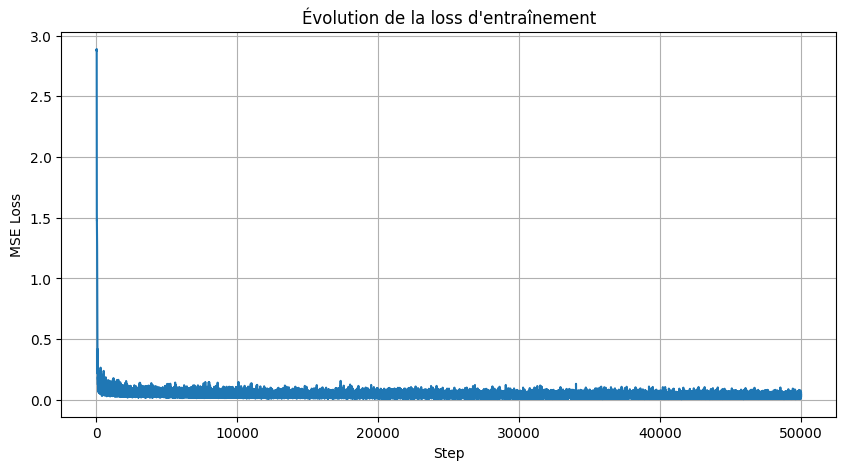

Loss CSV sauvegardé : /content/drive/MyDrive/DiffWave_Darija/results/diffwave_training_losses.csv
Figure sauvegardée : /content/drive/MyDrive/DiffWave_Darija/figures/diffwave_training_loss.png


In [225]:
loss_df = pd.DataFrame({
    "step": list(range(1, len(train_losses) + 1)),
    "train_loss": train_losses
})

loss_csv_path = RESULTS_DIR / "diffwave_training_losses.csv"
loss_df.to_csv(loss_csv_path, index=False)

plt.figure(figsize=(10, 5))
plt.plot(loss_df["step"], loss_df["train_loss"])
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Évolution de la loss d'entraînement")
plt.grid(True)
plt.show()

loss_fig_path = FIGURES_DIR / "diffwave_training_loss.png"

plt.figure(figsize=(10, 5))
plt.plot(loss_df["step"], loss_df["train_loss"])
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Évolution de la loss d'entraînement")
plt.grid(True)
plt.savefig(loss_fig_path, dpi=300, bbox_inches="tight")
plt.close()

print("Loss CSV sauvegardé :", loss_csv_path)
print("Figure sauvegardée :", loss_fig_path)

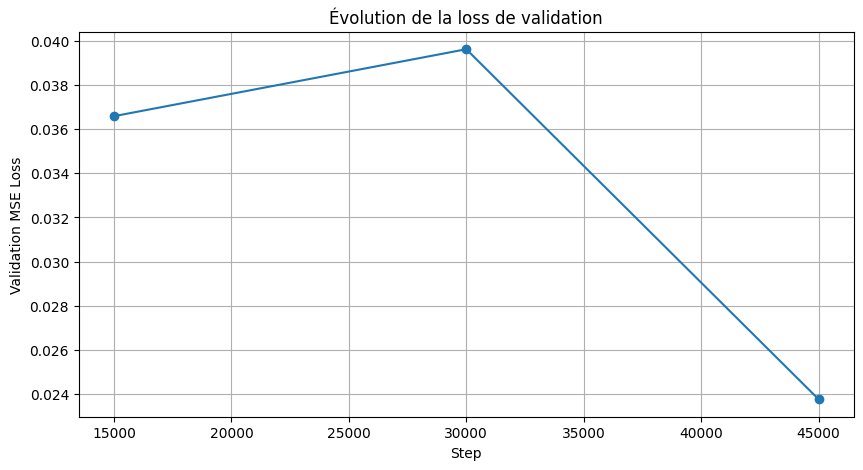

Validation CSV sauvegardé : /content/drive/MyDrive/DiffWave_Darija/results/diffwave_validation_losses.csv
Figure sauvegardée : /content/drive/MyDrive/DiffWave_Darija/figures/diffwave_validation_loss.png


In [226]:
if len(val_losses) > 0:
    val_loss_df = pd.DataFrame(val_losses)

    val_loss_csv_path = RESULTS_DIR / "diffwave_validation_losses.csv"
    val_loss_df.to_csv(val_loss_csv_path, index=False)

    plt.figure(figsize=(10, 5))
    plt.plot(val_loss_df["step"], val_loss_df["val_loss"], marker="o")
    plt.xlabel("Step")
    plt.ylabel("Validation MSE Loss")
    plt.title("Évolution de la loss de validation")
    plt.grid(True)
    plt.show()

    val_loss_fig_path = FIGURES_DIR / "diffwave_validation_loss.png"

    plt.figure(figsize=(10, 5))
    plt.plot(val_loss_df["step"], val_loss_df["val_loss"], marker="o")
    plt.xlabel("Step")
    plt.ylabel("Validation MSE Loss")
    plt.title("Évolution de la loss de validation")
    plt.grid(True)
    plt.savefig(val_loss_fig_path, dpi=300, bbox_inches="tight")
    plt.close()

    print("Validation CSV sauvegardé :", val_loss_csv_path)
    print("Figure sauvegardée :", val_loss_fig_path)
else:
    print("Aucune validation enregistrée.")

# Fin de l'entraînement

À ce stade, le modèle a été entraîné sur le dataset DODa prétraité.

Les fichiers importants sauvegardés sont :

- `best_checkpoint.pt` : meilleur modèle selon la validation ;
- `last_checkpoint.pt` : dernier modèle sauvegardé pendant l’entraînement ;
- `final_checkpoint.pt` : modèle final ;
- courbes de loss pour le rapport.

La prochaine étape sera la génération audio à partir d’un spectrogramme Mel du jeu de test.

# Génération audio avec le modèle DiffWave entraîné

Dans cette partie, on utilise le modèle entraîné pour générer de l'audio à partir d'un spectrogramme Mel.

Le principe est le suivant :

1. On charge le meilleur checkpoint sauvegardé pendant l'entraînement.
2. On prend un exemple du jeu de test.
3. On utilise son Mel spectrogram comme condition.
4. On part d'un bruit blanc aléatoire.
5. On applique progressivement le processus inverse de diffusion.
6. On obtient une waveform audio générée.
7. On compare l'audio généré avec l'audio original.

In [227]:
# Chargement du meilleur checkpoint entraîné

best_checkpoint_path = EXPERIMENT_DIR / "best_checkpoint.pt"
last_checkpoint_path = EXPERIMENT_DIR / "last_checkpoint.pt"
final_checkpoint_path = EXPERIMENT_DIR / "final_checkpoint.pt"

# On choisit le meilleur checkpoint disponible
if best_checkpoint_path.exists():
    checkpoint_path = best_checkpoint_path
elif final_checkpoint_path.exists():
    checkpoint_path = final_checkpoint_path
elif last_checkpoint_path.exists():
    checkpoint_path = last_checkpoint_path
else:
    checkpoint_path = None

if checkpoint_path is not None:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    print("Checkpoint chargé :", checkpoint_path)
    print("Step du checkpoint :", checkpoint.get("step", "inconnu"))

else:
    print("Aucun checkpoint trouvé.")
    print("Le modèle actuellement en mémoire sera utilisé.")
    model.eval()

Checkpoint chargé : /content/drive/MyDrive/DiffWave_Darija/checkpoints/diffwave_doda_male/best_checkpoint.pt
Step du checkpoint : 45000


## Préparation du jeu de test

On utilise maintenant `test.csv`, qui contient les exemples réservés à l’évaluation.

Pour la génération, on a besoin :

- du Mel spectrogram comme entrée du modèle ;
- de l’audio original pour comparer avec l’audio généré.

In [228]:
# Pour la génération, on charge le mel COMPLET (non croppé) directement depuis le .npy
# afin de produire un audio de durée réelle (et non le crop de 0,72s utilisé à l'entraînement).

print("Nombre d'exemples test :", len(test_df))
print("Les mels complets seront chargés directement depuis le disque pour la génération.")


## Fonction de génération

La fonction suivante applique le processus inverse de diffusion.

On part d’un bruit blanc aléatoire, puis le modèle prédit à chaque étape le bruit à retirer.  
À la fin du processus, on obtient un signal audio généré.

In [229]:
@torch.no_grad()
def p_sample(model, x, diffusion_step, mel):
    """
    Une étape de diffusion inverse.

    x doit avoir la shape [B, T].
    mel doit avoir la shape [B, 80, F].
    """

    # Sécurité : si x est [B, 1, T], on enlève la dimension inutile
    if x.dim() == 3:
        x = x.squeeze(1)

    batch_size = x.shape[0]

    t = torch.full(
        (batch_size,),
        diffusion_step,
        device=device,
        dtype=torch.long
    )

    predicted_noise = model(x, t, mel)

    # Sécurité : predicted_noise doit aussi être [B, T]
    if predicted_noise.dim() == 3:
        predicted_noise = predicted_noise.squeeze(1)

    beta_t = noise_schedule[diffusion_step]
    alpha_t = alphas[diffusion_step]
    alpha_cumprod_t = alpha_cumprod[diffusion_step]

    coef = beta_t / torch.sqrt(1.0 - alpha_cumprod_t)

    mean = (1.0 / torch.sqrt(alpha_t)) * (x - coef * predicted_noise)

    if diffusion_step > 0:
        noise = torch.randn_like(x)
        sigma = torch.sqrt(beta_t)
        x_prev = mean + sigma * noise
    else:
        x_prev = mean

    return x_prev


@torch.no_grad()
def generate_audio_from_mel(model, mel, audio_length):
    """
    Génère un audio à partir d'un Mel spectrogram.

    Le modèle DiffWave attend :
    - audio : [B, T]
    - mel : [B, 80, F]
    """

    model.eval()

    if mel.dim() == 2:
        mel = mel.unsqueeze(0)

    mel = mel.to(device)

    # Important : x doit être [B, T], pas [B, 1, T]
    x = torch.randn(
        mel.shape[0],
        audio_length,
        device=device
    )

    for step in tqdm(
        reversed(range(NUM_DIFFUSION_STEPS)),
        total=NUM_DIFFUSION_STEPS,
        desc="Génération"
    ):
        x = p_sample(model, x, step, mel)

    # Normalisation finale
    x = x / (x.abs().max(dim=1, keepdim=True)[0] + 1e-8)

    return x

## Génération d’un premier exemple

On sélectionne un exemple du jeu de test, puis on génère l’audio correspondant à partir de son Mel spectrogram.

On pourra ensuite écouter :

- l’audio original ;
- l’audio généré.

In [230]:
# Chargement pleine durée du 1er exemple de test

row = test_df.iloc[0]

# Chemin vers le mel complet
mel_path = Path(row["mel_path"])
if not mel_path.exists():
    mel_path = MEL_DIR / f"{str(row['id']).zfill(5)}.npy"

# Mel complet [80, F]
mel_full = np.load(mel_path).astype(np.float32)
audio_length = mel_full.shape[1] * summary["hop_length"]

# Audio original complet
wav_path = Path(row["wav_path"])
if not wav_path.exists():
    wav_path = WAV_DIR / f"{str(row['id']).zfill(5)}.wav"
original_audio_np, _ = sf.read(wav_path)
if original_audio_np.ndim > 1:
    original_audio_np = original_audio_np.mean(axis=1)
original_audio_np = original_audio_np.astype(np.float32)
# Aligner sur la longueur mel-dérivée
if len(original_audio_np) < audio_length:
    original_audio_np = np.pad(original_audio_np, (0, audio_length - len(original_audio_np)))
else:
    original_audio_np = original_audio_np[:audio_length]

example_id = row["id"]
example_speaker = row["speaker"]
example_text = row.get("text_latin", "")

mel = torch.tensor(mel_full, dtype=torch.float32).unsqueeze(0).to(device)

print("ID :", example_id)
print("Speaker :", example_speaker)
print("Texte :", example_text)
print("Mel frames :", mel_full.shape[1])
print(f"Audio length : {audio_length} samples | Durée : {audio_length/summary['sample_rate']:.2f}s")
print("Mel shape :", mel.shape)


In [231]:
generated_audio = generate_audio_from_mel(
    model=model,
    mel=mel,
    audio_length=audio_length
)

print("Audio généré shape :", generated_audio.shape)

Génération:   0%|          | 0/50 [00:00<?, ?it/s]

Audio généré shape : torch.Size([1, 15872])


## Sauvegarde et écoute

On sauvegarde l’audio généré au format `.wav`, puis on écoute l’original et le généré directement dans le notebook.

In [232]:
from IPython.display import Audio, display

GENERATED_DIR = PROJECT_DIR / "generated_audios"
GENERATED_DIR.mkdir(parents=True, exist_ok=True)

generated_audio_np = generated_audio[0].detach().cpu().numpy()
original_audio_np = original_audio[0].detach().cpu().numpy()

generated_audio_path = GENERATED_DIR / f"generated_{str(example_id).zfill(5)}.wav"

sf.write(
    generated_audio_path,
    generated_audio_np,
    summary["sample_rate"]
)

print("Audio généré sauvegardé ici :")
print(generated_audio_path)

Audio généré sauvegardé ici :
/content/drive/MyDrive/DiffWave_Darija/generated_audios/generated_tensor(3757).wav


In [233]:
print("Audio original :")
display(Audio(original_audio_np, rate=summary["sample_rate"]))

print("Audio généré :")
display(Audio(generated_audio_np, rate=summary["sample_rate"]))

Audio original :


Audio généré :


## Comparaison visuelle

On compare maintenant l’audio original et l’audio généré sous forme de waveform.

Cette visualisation permet de vérifier rapidement si le signal généré présente une structure ou s’il ressemble seulement à du bruit.

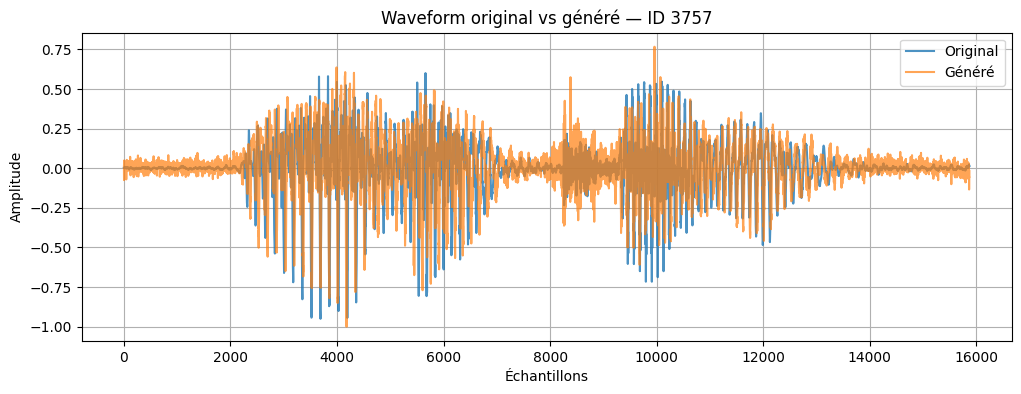

Figure sauvegardée ici :
/content/drive/MyDrive/DiffWave_Darija/figures/waveform_original_vs_generated_tensor(3757).png


In [234]:
plt.figure(figsize=(12, 4))
plt.plot(original_audio_np, label="Original", alpha=0.8)
plt.plot(generated_audio_np, label="Généré", alpha=0.7)
plt.title(f"Waveform original vs généré — ID {example_id}")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

waveform_comparison_path = FIGURES_DIR / f"waveform_original_vs_generated_{str(example_id).zfill(5)}.png"

plt.figure(figsize=(12, 4))
plt.plot(original_audio_np, label="Original", alpha=0.8)
plt.plot(generated_audio_np, label="Généré", alpha=0.7)
plt.title(f"Waveform original vs généré — ID {example_id}")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.savefig(waveform_comparison_path, dpi=300, bbox_inches="tight")
plt.close()

print("Figure sauvegardée ici :")
print(waveform_comparison_path)

## Spectrogramme Mel de l’audio généré

On calcule le Mel spectrogram de l’audio généré afin de le comparer visuellement avec le Mel utilisé comme condition.

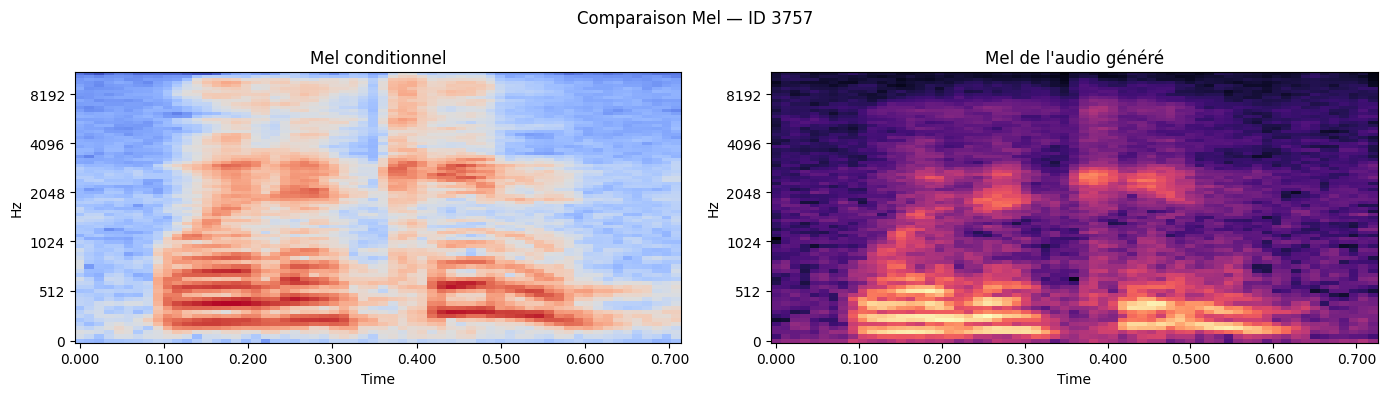

Figure sauvegardée ici :
/content/drive/MyDrive/DiffWave_Darija/figures/mel_condition_vs_generated_tensor(3757).png


In [235]:
generated_mel = librosa.feature.melspectrogram(
    y=generated_audio_np,
    sr=summary["sample_rate"],
    n_fft=summary["n_fft"],
    hop_length=summary["hop_length"],
    win_length=summary["n_fft"],
    n_mels=summary["n_mels"],
    power=1.0
)

generated_mel_log = np.log(np.clip(generated_mel, 1e-5, None))
generated_mel_log = np.clip(generated_mel_log, -11.5, None)

condition_mel = mel[0].detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

librosa.display.specshow(
    condition_mel,
    sr=summary["sample_rate"],
    hop_length=summary["hop_length"],
    x_axis="time",
    y_axis="mel",
    ax=axes[0]
)
axes[0].set_title("Mel conditionnel")

librosa.display.specshow(
    generated_mel_log,
    sr=summary["sample_rate"],
    hop_length=summary["hop_length"],
    x_axis="time",
    y_axis="mel",
    ax=axes[1]
)
axes[1].set_title("Mel de l'audio généré")

plt.suptitle(f"Comparaison Mel — ID {example_id}")
plt.tight_layout()
plt.show()

mel_comparison_path = FIGURES_DIR / f"mel_condition_vs_generated_{str(example_id).zfill(5)}.png"

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

librosa.display.specshow(
    condition_mel,
    sr=summary["sample_rate"],
    hop_length=summary["hop_length"],
    x_axis="time",
    y_axis="mel",
    ax=axes[0]
)
axes[0].set_title("Mel conditionnel")

librosa.display.specshow(
    generated_mel_log,
    sr=summary["sample_rate"],
    hop_length=summary["hop_length"],
    x_axis="time",
    y_axis="mel",
    ax=axes[1]
)
axes[1].set_title("Mel de l'audio généré")

plt.suptitle(f"Comparaison Mel — ID {example_id}")
plt.tight_layout()
plt.savefig(mel_comparison_path, dpi=300, bbox_inches="tight")
plt.close()

print("Figure sauvegardée ici :")
print(mel_comparison_path)

## Génération de plusieurs exemples

On génère maintenant plusieurs audios à partir du jeu de test.

Les résultats sont sauvegardés dans un dossier dédié et récapitulés dans un fichier CSV.

In [236]:
NUM_EXAMPLES_TO_GENERATE = 5

generated_results = []

model.eval()

for i in range(NUM_EXAMPLES_TO_GENERATE):
    row = test_df.iloc[i]

    # Charger le mel complet
    mel_path_i = Path(row["mel_path"])
    if not mel_path_i.exists():
        mel_path_i = MEL_DIR / f"{str(row['id']).zfill(5)}.npy"
    mel_full_i = np.load(mel_path_i).astype(np.float32)  # [80, F]

    # Charger l'audio original complet
    wav_path_i = Path(row["wav_path"])
    if not wav_path_i.exists():
        wav_path_i = WAV_DIR / f"{str(row['id']).zfill(5)}.wav"

    mel_i = torch.tensor(mel_full_i, dtype=torch.float32).unsqueeze(0).to(device)
    audio_length_i = mel_full_i.shape[1] * summary["hop_length"]
    duration_s = audio_length_i / summary["sample_rate"]

    sample_id = str(row["id"]).zfill(5)
    speaker = row["speaker"]
    text = row.get("text_latin", "")

    gen_audio_i = generate_audio_from_mel(
        model=model,
        mel=mel_i,
        audio_length=audio_length_i
    )

    gen_audio_np_i = gen_audio_i[0].detach().cpu().numpy()

    output_path = GENERATED_DIR / f"generated_{sample_id}.wav"
    sf.write(output_path, gen_audio_np_i, summary["sample_rate"])

    generated_results.append({
        "id": sample_id,
        "speaker": speaker,
        "text_latin": text,
        "duration_s": round(duration_s, 3),
        "mel_frames": mel_full_i.shape[1],
        "generated_audio_path": str(output_path)
    })

    print(f"Exemple {i+1}/{NUM_EXAMPLES_TO_GENERATE} | ID {sample_id} | {mel_full_i.shape[1]} frames | {duration_s:.2f}s → {output_path.name}")


In [237]:
generated_results_df = pd.DataFrame(generated_results)

generated_results_path = RESULTS_DIR / "generated_audio_results.csv"
generated_results_df.to_csv(generated_results_path, index=False)

print("Résultats sauvegardés ici :")
print(generated_results_path)

display(generated_results_df)

Résultats sauvegardés ici :
/content/drive/MyDrive/DiffWave_Darija/results/generated_audio_results.csv


,id,speaker,text_latin,generated_audio_path
0,03757,M2,walakin nta kan 3ndk jtima3 S3ib,/content/drive/MyDrive/DiffWave_Darija/generat...
1,10384,M1,redlbal,/content/drive/MyDrive/DiffWave_Darija/generat...
2,04938,M1,momkin tabghiha 9bal mosi9a dyal rock,/content/drive/MyDrive/DiffWave_Darija/generat...
3,11678,M1,kaystresse mli katchouf nass a5rin ki5niw,/content/drive/MyDrive/DiffWave_Darija/generat...
4,03633,M2,nta katbi3 otchri f achmn naw3 dyal nifT?,/content/drive/MyDrive/DiffWave_Darija/generat...


In [238]:
for _, row in generated_results_df.iterrows():
    print("ID :", row["id"])
    print("Speaker :", row["speaker"])
    print("Texte :", row["text_latin"])
    display(Audio(row["generated_audio_path"], rate=summary["sample_rate"]))

ID : 03757
Speaker : M2
Texte : walakin nta kan 3ndk jtima3 S3ib


ID : 10384
Speaker : M1
Texte : redlbal


ID : 04938
Speaker : M1
Texte : momkin tabghiha 9bal mosi9a dyal rock


ID : 11678
Speaker : M1
Texte : kaystresse mli katchouf nass a5rin ki5niw


ID : 03633
Speaker : M2
Texte : nta katbi3 otchri f achmn naw3 dyal nifT?


## Évaluation qualitative

Les audios générés peuvent être évalués manuellement selon plusieurs critères :

- qualité sonore générale ;
- niveau de bruit ;
- stabilité du signal ;
- ressemblance avec une voix humaine ;
- cohérence avec le Mel conditionnel.

Si l’entraînement est court, il est normal que les audios soient encore bruités.  
Dans ce cas, l’objectif principal est de montrer que le pipeline complet fonctionne.

In [239]:
evaluation_df = pd.DataFrame({
    "id": generated_results_df["id"],
    "speaker": generated_results_df["speaker"],
    "quality_score_1_to_5": [None] * len(generated_results_df),
    "noise_level_1_to_5": [None] * len(generated_results_df),
    "voice_naturalness_1_to_5": [None] * len(generated_results_df),
    "comments": [None] * len(generated_results_df)
})

evaluation_path = RESULTS_DIR / "qualitative_evaluation_template.csv"
evaluation_df.to_csv(evaluation_path, index=False)

print("Template d'évaluation sauvegardé ici :")
print(evaluation_path)

display(evaluation_df)

Template d'évaluation sauvegardé ici :
/content/drive/MyDrive/DiffWave_Darija/results/qualitative_evaluation_template.csv


,id,speaker,quality_score_1_to_5,noise_level_1_to_5,voice_naturalness_1_to_5,comments
0,03757,M2,None,None,None,None
1,10384,M1,None,None,None,None
2,04938,M1,None,None,None,None
3,11678,M1,None,None,None,None
4,03633,M2,None,None,None,None


# Fin de la génération audio

À ce stade, le pipeline complet est réalisé :

1. données prétraitées ;
2. Dataset PyTorch ;
3. modèle DiffWave ;
4. entraînement ;
5. sauvegarde du checkpoint ;
6. génération audio ;
7. comparaison original / généré ;
8. préparation de l’évaluation qualitative.

Les résultats générés peuvent maintenant être utilisés dans le rapport et la présentation.